In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../01-Data-Preprocessing/jdm_used_cars_cleaned.csv')

X_cluster = df[['price', 'mileage']].copy()

print("Data siap untuk dikelompokkan oleh K-Means!")
display(X_cluster.head())

Data siap untuk dikelompokkan oleh K-Means!


,price,mileage
0,165,-1.182687
1,190,0.846600
2,190,-0.727528
3,190,-0.358215
4,220,0.512482


In [2]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

label_geng = kmeans.fit_predict(X_cluster)

df['Cluster'] = label_geng
X_cluster['Cluster'] = label_geng

print("Mobil berhasil dikelompokkan ke dalam 3 Cluster!")
display(X_cluster.sample(5))

Mobil berhasil dikelompokkan ke dalam 3 Cluster!


,price,mileage,Cluster
1693,1213,2.028865,1
1435,1120,0.042599,1
421,690,0.047784,2
1777,1240,0.732602,1
2134,1355,0.414651,1


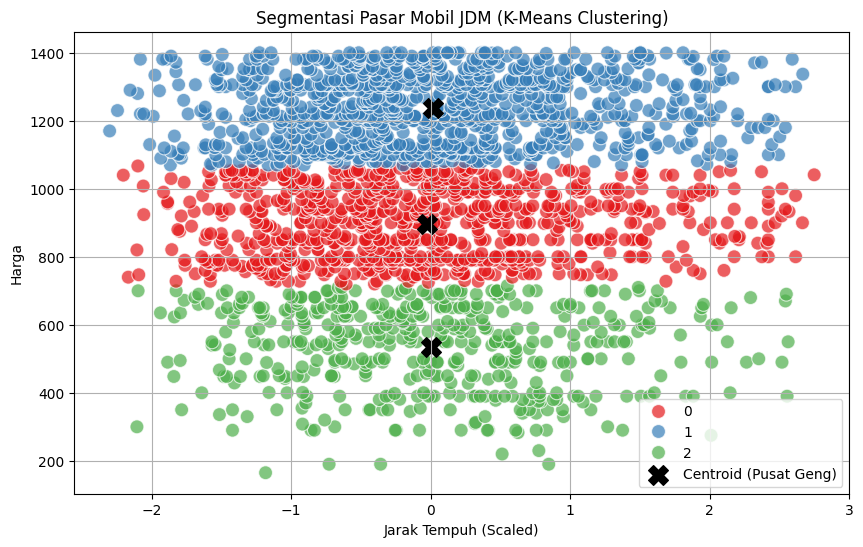

In [3]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x='mileage', y='price', hue='Cluster', data=X_cluster, palette='Set1', s=100, alpha=0.7)

pusat_geng = kmeans.cluster_centers_
plt.scatter(pusat_geng[:, 1], pusat_geng[:, 0], color='black', marker='X', s=200, label='Centroid (Pusat Geng)')

plt.title('Segmentasi Pasar Mobil JDM (K-Means Clustering)')
plt.xlabel('Jarak Tempuh (Scaled)')
plt.ylabel('Harga')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
# Menghitung nilai rata-rata tiap kolom berdasarkan geng (Cluster)
profil_geng = X_cluster.groupby('Cluster').mean().round(2)

# Mengurutkan berdasarkan harga dari yang termurah ke termahal
profil_geng = profil_geng.sort_values(by='price')

print("📊 --- PROFIL KARAKTERISTIK SEGMEN PASAR --- 📊")
display(profil_geng)

📊 --- PROFIL KARAKTERISTIK SEGMEN PASAR --- 📊


,price,mileage
Cluster,,
2,534.24,0.01
0,897.60,-0.03
1,1238.25,0.02


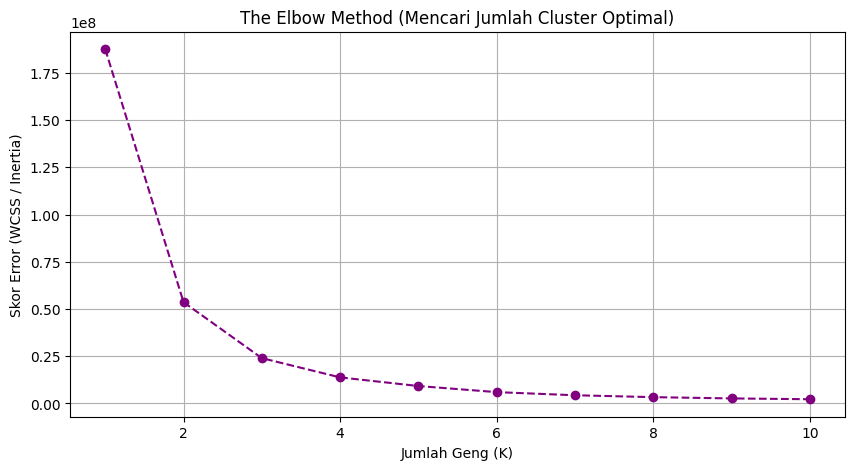

In [5]:
# Menyimpan skor error untuk setiap jumlah cluster
wcss = []

# Mencoba membuat model dari K=1 sampai K=10
for i in range(1, 11):
    kmeans_test = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans_test.fit(X_cluster[['price', 'mileage']])
    # inertia_ adalah nilai WCSS (Within-Cluster Sum of Square)
    wcss.append(kmeans_test.inertia_)

# Membuat Visualisasi Garis
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='purple')
plt.title('The Elbow Method (Mencari Jumlah Cluster Optimal)')
plt.xlabel('Jumlah Geng (K)')
plt.ylabel('Skor Error (WCSS / Inertia)')
plt.grid(True)
plt.show()

In [6]:
from sklearn.decomposition import PCA

# 1. Menyiapkan seluruh data utuh (membuang kolom 'Cluster' hasil tebakan kemarin)
X_utuh = df.drop(columns=['Cluster'], errors='ignore')

# 2. Inisialisasi PCA untuk memeras data menjadi 2 dimensi (2 kolom)
pca = PCA(n_components=2, random_state=42)

# 3. Proses pemerasan (Transformasi)
X_pca = pca.fit_transform(X_utuh)

# 4. Membungkus hasilnya menjadi DataFrame baru
df_pca = pd.DataFrame(data=X_pca, columns=['Komponen_Utama_1', 'Komponen_Utama_2'])

print("Data asli memiliki", X_utuh.shape[1], "kolom.")
print("Setelah di-PCA, data kini hanya memiliki", df_pca.shape[1], "kolom!")
display(df_pca.head())

Data asli memiliki 40 kolom.
Setelah di-PCA, data kini hanya memiliki 2 kolom!


,Komponen_Utama_1,Komponen_Utama_2
0,-807.958755,-0.064481
1,-782.958679,1.487971
2,-782.960129,-1.268300
3,-782.959695,-1.028734
4,-752.960549,0.467542


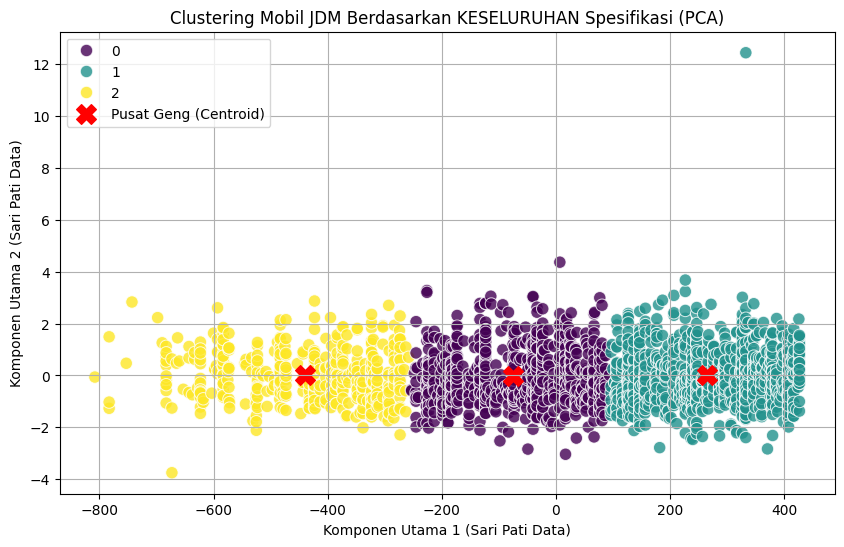

In [7]:
# 1. Melatih ulang K-Means (K=3) menggunakan data hasil perasan PCA
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
df_pca['Cluster_Baru'] = kmeans_pca.fit_predict(df_pca)

# 2. Visualisasi Peta Persebaran Mobil JDM yang Komprehensif
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Komponen_Utama_1', 
    y='Komponen_Utama_2', 
    hue='Cluster_Baru', 
    data=df_pca, 
    palette='viridis', 
    s=80, 
    alpha=0.8
)

# 3. Menandai pusat dari masing-masing geng baru
pusat_pca = kmeans_pca.cluster_centers_
plt.scatter(pusat_pca[:, 0], pusat_pca[:, 1], color='red', marker='X', s=200, label='Pusat Geng (Centroid)')

plt.title('Clustering Mobil JDM Berdasarkan KESELURUHAN Spesifikasi (PCA)')
plt.xlabel('Komponen Utama 1 (Sari Pati Data)')
plt.ylabel('Komponen Utama 2 (Sari Pati Data)')
plt.legend()
plt.grid(True)
plt.show()